# 2. Spatially varying parameters

A groundwater model needs recharge in every cell, and recharge depends on
soil, vegetation and depth to the water table, all of which vary across a
catchment. The usual LUMPREM workflow ran a handful of representative
models, one per soil and land-use combination, and mapped their output onto
zones. `ModelGrid` removes the need to choose: one model per cell, each with
its own parameters, run together.

This notebook:

1. builds a synthetic valley with soil, land-use, regolith and water-table
   maps;
2. turns class tables and continuous maps into per-cell parameters;
3. runs the grid under one shared climate and maps the water budget;
4. looks at individual cells, and checks one against a single-site run;
5. mixes one- and two-store cells in one grid;
6. times the compiled and pure-Python engines.

Forcing that varies from cell to cell — a rainfall gradient, crop calendars,
irrigation districts — is the subject of
[notebook 3](03_spatial_forcing.ipynb).

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

import herebedragons as hbd
import lumpyrem as lr

## 1. The landscape

`herebedragons.py`, next to this notebook, builds a 10 km by 15 km valley on
a 250 m grid: 40 rows by 60 columns, 2,400 cells. It is synthetic, made from
smooth random fields with a fixed seed. A river runs north down the middle;
clay on the flat valley floor gives way to loam on the slopes and sand on the
ridges. Irrigated crops sit on the floor, pasture on the slopes and native
vegetation on the ridges. A buried palaeochannel of deep regolith meanders
along the valley, and the unsaturated zone thickens from 4 m near the river
to over 60 m under the ridges.

In [2]:
land = hbd.synthetic_landscape()
land

<xarray.Dataset> Size: 80kB
Dimensions:          (y: 40, x: 60)
Coordinates:
  * y                (y) float64 320B 125.0 375.0 625.0 ... 9.625e+03 9.875e+03
  * x                (x) float64 480B 125.0 375.0 625.0 ... 1.462e+04 1.488e+04
Data variables:
    dem              (y, x) float64 19kB 248.2 244.9 241.7 ... 259.1 265.4 271.6
    soil             (y, x) int64 19kB 0 0 0 0 0 0 0 0 1 1 ... 1 1 1 0 0 0 0 0 0
    landuse          (y, x) int64 19kB 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 0 0 0 0 0
    deep_regolith    (y, x) bool 2kB False False False ... False False False
    unsat_thickness  (y, x) float64 19kB 43.9 42.38 40.96 ... 48.81 51.62 54.41

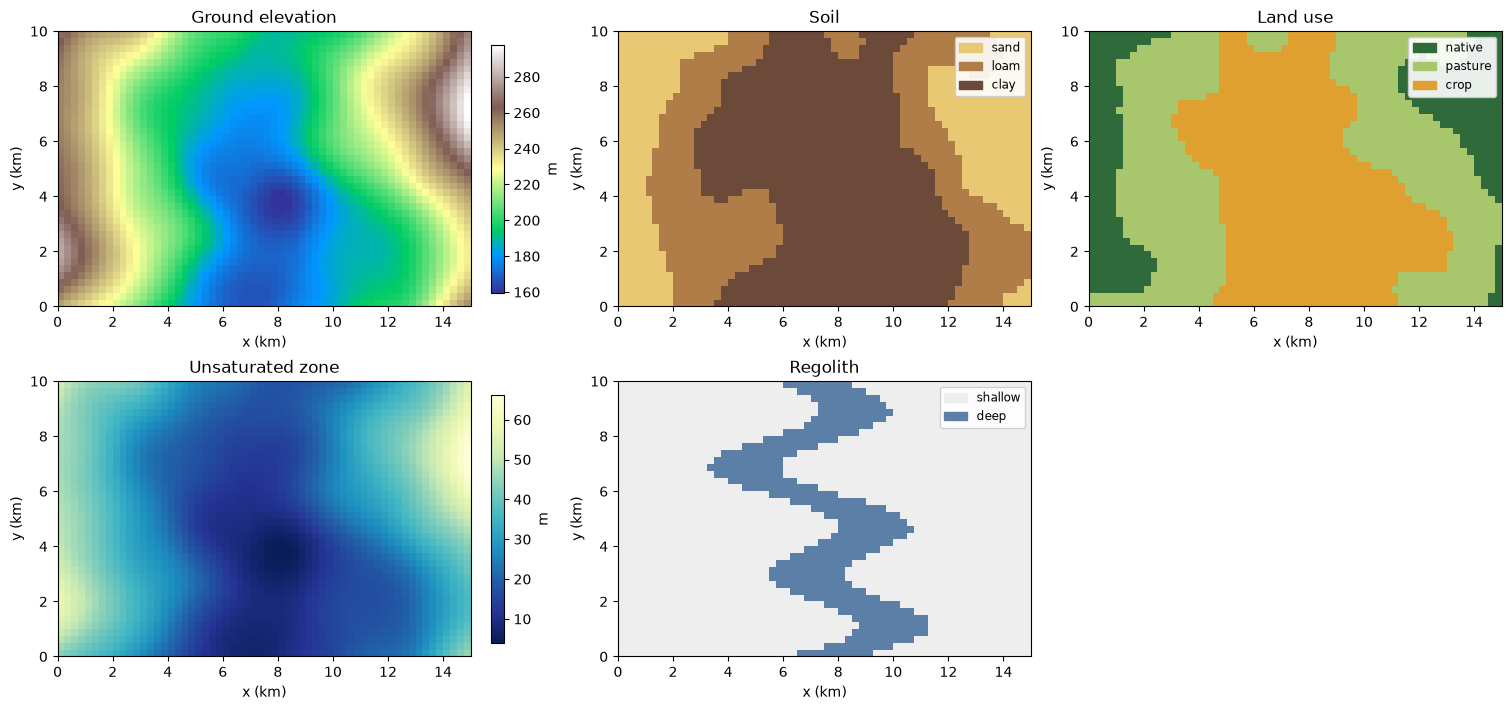

In [3]:
fig, axs = plt.subplots(2, 3, figsize=(15, 7), layout="constrained")
hbd.plot_map(axs[0, 0], land.dem, land, title="Ground elevation", label="m", cmap="terrain")
hbd.plot_classes(axs[0, 1], land.soil, land, hbd.SOIL_CLASSES, hbd.SOIL_COLORS,
                 title="Soil")
hbd.plot_classes(axs[0, 2], land.landuse, land, hbd.LANDUSE_CLASSES, hbd.LANDUSE_COLORS,
                 title="Land use")
hbd.plot_map(axs[1, 0], land.unsat_thickness, land, title="Unsaturated zone",
             label="m", cmap="YlGnBu_r")
hbd.plot_classes(axs[1, 1], land.deep_regolith.astype(int), land, ("shallow", "deep"),
                 ("#eeeeee", "#5b7fa6"), title="Regolith")
axs[1, 2].axis("off");

## 2. From maps to parameters

A `ModelGrid` numbers its cells 0 to N−1. Here they are numbered row by row,
which is what NumPy's `ravel` gives, so cell `k` is row `k // 60`, column
`k % 60`, and a per-cell array reshapes straight back into a map.

Soil sets the drainage parameters and the water a metre of soil can hold;
land use sets the rooting depth and whether the cell is irrigated. These are
ordinary DataFrames, one row per class — edit them and re-run.

In [4]:
soils = pd.DataFrame(
    {"awc": [0.10, 0.15, 0.18],          # plant-available water, m per m of root depth
     "ks": [0.8, 0.2, 0.03],             # m/day
     "m": [0.6, 0.5, 0.4],
     "mflowmax": [0.0, 0.0, 0.01]},      # macropore flow cap, m/day: cracking clay only
    index=pd.Index(hbd.SOIL_CLASSES, name="soil"),
)
landuse = pd.DataFrame(
    {"root_depth": [2.0, 1.0, 1.2],      # m
     "irrigvolfrac": [0.0, 0.0, 0.4]},   # irrigation tops the store up to this fraction
    index=pd.Index(hbd.LANDUSE_CLASSES, name="landuse"),
)
soils, landuse

(       awc    ks    m  mflowmax
 soil                           
 sand  0.10  0.80  0.6      0.00
 loam  0.15  0.20  0.5      0.00
 clay  0.18  0.03  0.4      0.01,
          root_depth  irrigvolfrac
 landuse                          
 native          2.0           0.0
 pasture         1.0           0.0
 crop            1.2           0.4)

Indexing a class table by each cell's class code gives a table with one row
per cell. Two parameters then combine a class value with a map:

- `maxvol`, the store at field capacity, is available water times rooting
  depth, so it depends on both soil and land use;
- `rdelay` grows with the thickness of the unsaturated zone, here at an
  assumed 3 days per metre, for the time drainage takes to reach the water
  table.

In [5]:
soil_code = land.soil.values.ravel()
use_code = land.landuse.values.ravel()
unsat = land.unsat_thickness.values.ravel()

cells = pd.concat([soils.iloc[soil_code].reset_index(),
                   landuse.iloc[use_code].reset_index()], axis=1)
cells["maxvol"] = cells["awc"] * cells["root_depth"]
cells["rdelay"] = 3.0 * unsat
cells.head()

,soil,awc,ks,m,mflowmax,landuse,root_depth,irrigvolfrac,maxvol,rdelay
0,sand,0.1,0.8,0.6,0.0,pasture,1.0,0.0,0.1,131.707096
1,sand,0.1,0.8,0.6,0.0,pasture,1.0,0.0,0.1,127.153153
2,sand,0.1,0.8,0.6,0.0,pasture,1.0,0.0,0.1,122.885687
3,sand,0.1,0.8,0.6,0.0,pasture,1.0,0.0,0.1,118.873900
4,sand,0.1,0.8,0.6,0.0,pasture,1.0,0.0,0.1,115.074119


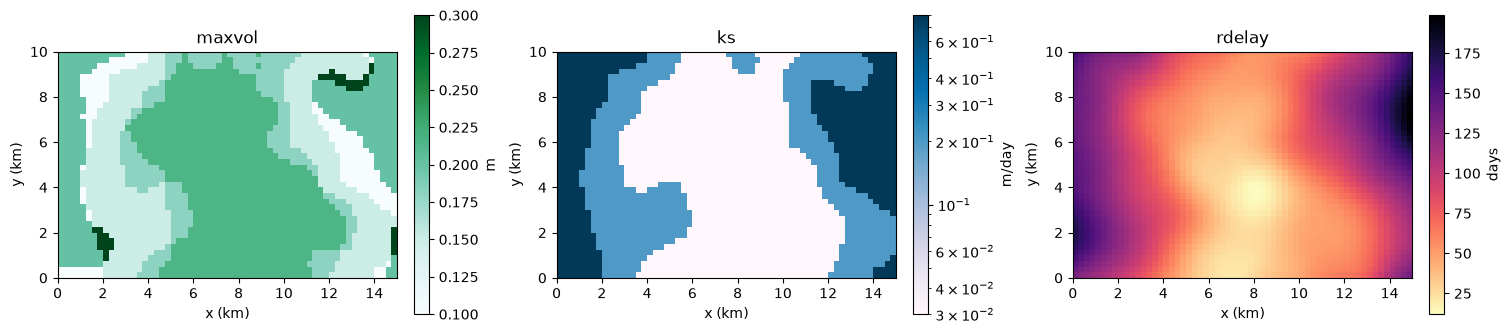

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.6), layout="constrained")
hbd.plot_map(axs[0], cells["maxvol"], land, title="maxvol", label="m", cmap="BuGn")
hbd.plot_map(axs[1], cells["ks"], land, title="ks", label="m/day", cmap="PuBu",
             norm=LogNorm())
hbd.plot_map(axs[2], cells["rdelay"], land, title="rdelay", label="days", cmap="magma_r");

## 3. The grid

`ModelGrid.from_arrays` takes the fields of each parameter object as a
mapping. A 1-D array gives one value per cell; a number is shared by every
cell. Here the upper store and the initial state vary, and every cell starts
half full. Every cell is validated as a single `Model` would be, and an
error names the cell.

In [7]:
grid = lr.ModelGrid.from_arrays(
    upper=dict(
        maxvol=cells["maxvol"].to_numpy(),
        ks=cells["ks"].to_numpy(),
        m=cells["m"].to_numpy(),
        l=0.5,
        mflowmax=cells["mflowmax"].to_numpy(),
        irrigvolfrac=cells["irrigvolfrac"].to_numpy(),
        rdelay=cells["rdelay"].to_numpy(),
        mdelay=1.0,
    ),
    initial=dict(vol=0.5 * cells["maxvol"].to_numpy()),
    solver=lr.Solver(nstep=5),
)
grid

<ModelGrid: 2400 cells, 0 with a lower store>

In [8]:
try:
    lr.ModelGrid.from_arrays(upper=dict(maxvol=cells["maxvol"].to_numpy(), ks=0.2,
                                        m=np.where(soil_code == 2, 0.0, 0.5), l=0.5))
except lr.ModelError as err:
    print(err)

cell 14: UpperStore.m must be > 0 (the drainage law takes 1/m); got 0.0


### One climate for every cell

The forcing is the climate from notebook 1, shared by every cell, with
irrigation allowed from October to March. The `irrigate` flag is the same
everywhere, but only cells with `irrigvolfrac > 0` — the crops — have
anything to top up, so irrigation is spatial through the parameters alone.
Half of the irrigation water is pumped from groundwater (`gw_irrig_frac`).

In [9]:
clim = hbd.load_climate()
irrigate = hbd.season_flag(clim.index, months=(10, 11, 12, 1, 2, 3))
forcing = lr.Forcing.from_dataframe(clim.assign(irrigate=irrigate),
                                    veg_gamma=3.0, gw_irrig_frac=0.5)

t0 = time.perf_counter()
results = grid.run(forcing, times="MS")
print(f"{grid.ncell} cells x {len(clim)} days in {time.perf_counter() - t0:.1f} s")
results

2400 cells x 3627 days in 0.9 s


<GridResults: 2400 cells x 120 output times, 1990-01-31 to 2000-01-01, converged>

The first run in a session includes compiling the kernel, unless Numba has it
cached already, so a second run is the fairer timing.

`results["total_rech"]` is a DataFrame, time by cell. Summing over time and
dividing by the length of the run gives a mean annual rate for every cell,
which reshapes into a map.

In [10]:
nyears = (clim.index[-1] - clim.index[0]).days / 365.25
annual = {name: results[name].sum() / nyears
          for name in ("rainfall", "irrigation", "evap_upper", "total_rech",
                       "gw_withdrawal", "net_recharge")}
annual["total_rech"].head()

cell
0    0.306288
1    0.306290
2    0.306303
3    0.306664
4    0.306813
dtype: float64

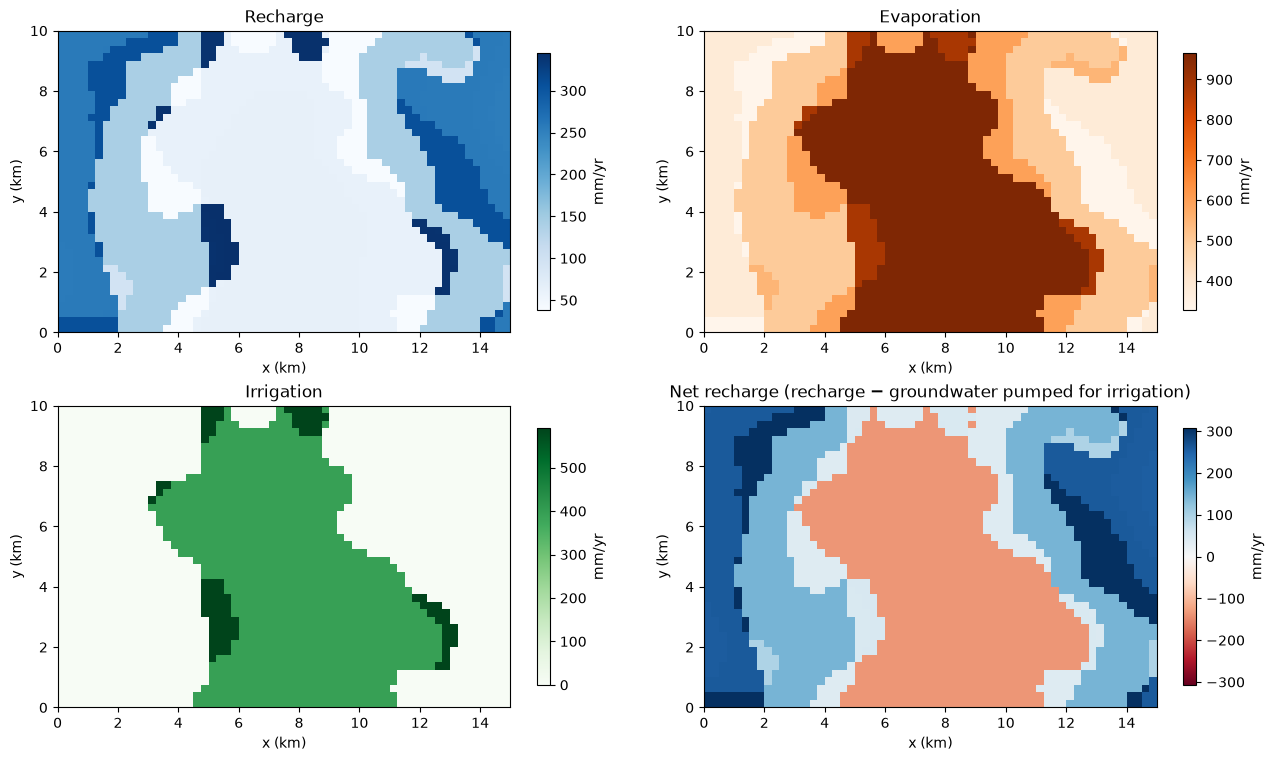

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5), layout="constrained")
hbd.plot_map(axs[0, 0], annual["total_rech"] * 1000, land, title="Recharge",
             label="mm/yr", cmap="Blues")
hbd.plot_map(axs[0, 1], annual["evap_upper"] * 1000, land, title="Evaporation",
             label="mm/yr", cmap="Oranges")
hbd.plot_map(axs[1, 0], annual["irrigation"] * 1000, land, title="Irrigation",
             label="mm/yr", cmap="Greens")
lim = float(np.abs(annual["net_recharge"]).max() * 1000)
hbd.plot_map(axs[1, 1], annual["net_recharge"] * 1000, land,
             title="Net recharge (recharge − groundwater pumped for irrigation)",
             label="mm/yr", cmap="RdBu", vmin=-lim, vmax=lim);

The ridges' sandy soils recharge most; the clay floor recharges least, except
where irrigation keeps the store wet. `net_recharge` subtracts the share of
irrigation pumped from the aquifer, which is what a groundwater model should
receive when the pumping is not represented separately.

The same numbers, summarised by class:

In [12]:
summary = pd.DataFrame({"soil": cells["soil"], "landuse": cells["landuse"],
                        "recharge_mm": annual["total_rech"].to_numpy() * 1000})
summary.pivot_table(index="soil", columns="landuse", values="recharge_mm",
                    aggfunc="mean").reindex(index=hbd.SOIL_CLASSES,
                                            columns=hbd.LANDUSE_CLASSES).round(0)

landuse,native,pasture,crop
soil,,,
sand,257.0,307.0,NaN
loam,95.0,142.0,342.0
clay,NaN,39.0,62.0


### Checking every cell

Convergence and the water balance are reported per cell.

In [13]:
results.converged, results.nonconverged_cells

(True, [])

In [14]:
balance = results.balance_error()
balance.groupby(cells["landuse"].to_numpy()).max()

crop       1.222113e-15
native     4.787837e-16
pasture    2.914335e-16
Name: balance_error, dtype: float64

Every cell converges and closes its balance to rounding. Two known defects
in `lumprem2.f`, reproduced on purpose, can open the balance in other setups;
`Results.balance_error` documents them, and a cell that stands out in this
check is the place to start.

## 4. Individual cells

`results.cell(k)` returns one cell's results exactly as `Model.run` would.
Four cells, one in each landscape position:

In [15]:
def pick(soil: int, use: int, soil_code: np.ndarray, use_code: np.ndarray) -> int:
    """The middle cell, in numbering order, with a given soil and land use."""
    match = np.flatnonzero((soil_code == soil) & (use_code == use))
    return int(match[len(match) // 2])


sites = {
    "A: ridge, sand, native": pick(0, 0, soil_code, use_code),
    "B: slope, loam, pasture": pick(1, 1, soil_code, use_code),
    "C: floor, clay, pasture": pick(2, 1, soil_code, use_code),
    "D: floor, clay, crop": pick(2, 2, soil_code, use_code),
}
cells.loc[list(sites.values()), ["soil", "landuse", "maxvol", "ks", "rdelay"]] \
    .set_axis(list(sites), axis=0)

,soil,landuse,maxvol,ks,rdelay
"A: ridge, sand, native",sand,native,0.200,0.80,139.567180
"B: slope, loam, pasture",loam,pasture,0.150,0.20,130.106651
"C: floor, clay, pasture",clay,pasture,0.180,0.03,62.118003
"D: floor, clay, crop",clay,crop,0.216,0.03,36.904868


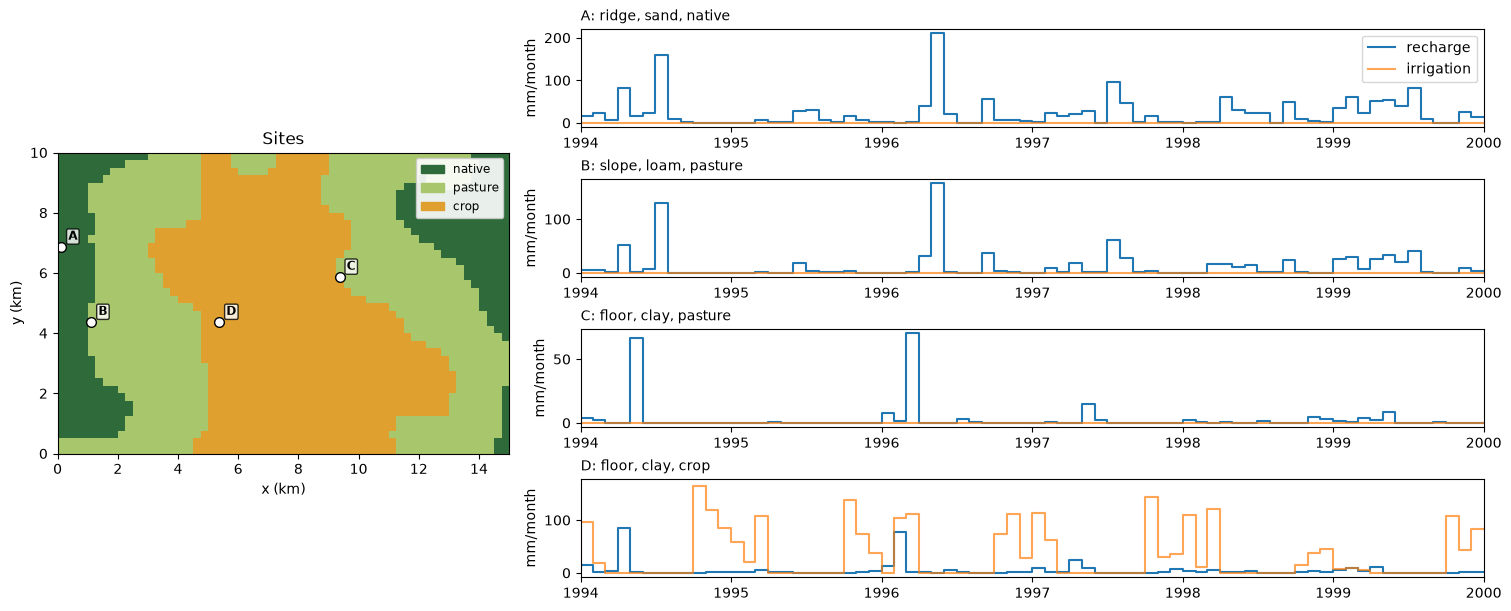

In [16]:
fig = plt.figure(figsize=(15, 6), layout="constrained")
gs = fig.add_gridspec(len(sites), 2, width_ratios=[1, 2])
ax_map = fig.add_subplot(gs[:, 0])
hbd.plot_classes(ax_map, land.landuse, land, hbd.LANDUSE_CLASSES, hbd.LANDUSE_COLORS,
                 title="Sites")
hbd.mark_cells(ax_map, sites.values(), land, labels=[s.split(":")[0] for s in sites])
for i, (name, k) in enumerate(sites.items()):
    ax = fig.add_subplot(gs[i, 1])
    one = results.cell(k).df
    ax.step(one.index, one["total_rech"] * 1000, label="recharge")
    ax.step(one.index, one["irrigation"] * 1000, label="irrigation", alpha=0.7)
    ax.set_ylabel("mm/month")
    ax.set_title(name, loc="left", fontsize="medium")
    ax.set_xlim(pd.Timestamp("1994-01-01"), pd.Timestamp("2000-01-01"))
    if i == 0:
        ax.legend(loc="upper right")

Every cell of a grid reproduces the same model run alone exactly, whichever
engine runs it; `grid[k]` is cell `k`'s `Model`.

In [17]:
k = sites["D: floor, clay, crop"]
alone = grid[k].run(forcing, times="MS")
np.array_equal(alone.values, results.cell(k).values, equal_nan=True)

True

### The effect of the delay

`rdelay` varies with the water-table depth, so the same storm reaches the
water table at different times in different cells. The next figure takes two
loam pasture cells, one with a thin unsaturated zone and one with a thick one,
and shows daily recharge through the wet summer of 1996. Water in transit sits
in the delay buffer, `vol_drain`.

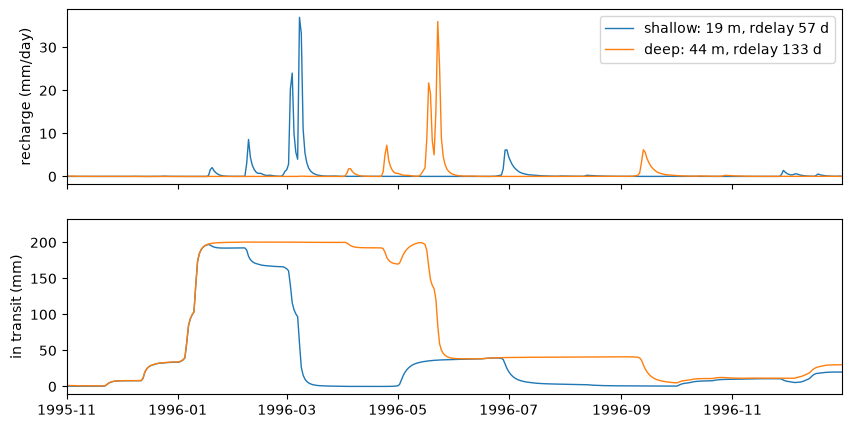

In [18]:
loam_pasture = np.flatnonzero((soil_code == 1) & (use_code == 1))
shallow = int(loam_pasture[np.argmin(unsat[loam_pasture])])
deep = int(loam_pasture[np.argmax(unsat[loam_pasture])])

pair = lr.ModelGrid(cells=(grid[shallow], grid[deep]), names=("shallow", "deep"))
pair_daily = pair.run(forcing, times=None)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for name, k in (("shallow", shallow), ("deep", deep)):
    label = f"{name}: {unsat[k]:.0f} m, rdelay {cells.at[k, 'rdelay']:.0f} d"
    ax1.plot(pair_daily.times, pair_daily["total_rech"][name] * 1000, label=label, lw=1)
    ax2.plot(pair_daily.times, pair_daily["vol_drain"][name] * 1000, lw=1)
ax1.set_ylabel("recharge (mm/day)")
ax2.set_ylabel("in transit (mm)")
ax1.legend()
ax1.set_xlim(pd.Timestamp("1995-11-01"), pd.Timestamp("1996-12-31"));

Year by year, the delay moves recharge across calendar boundaries: a wet
December under the ridges recharges in the following autumn. Each row of the
monthly results labels the end of its month, so a day is subtracted before
grouping by year.

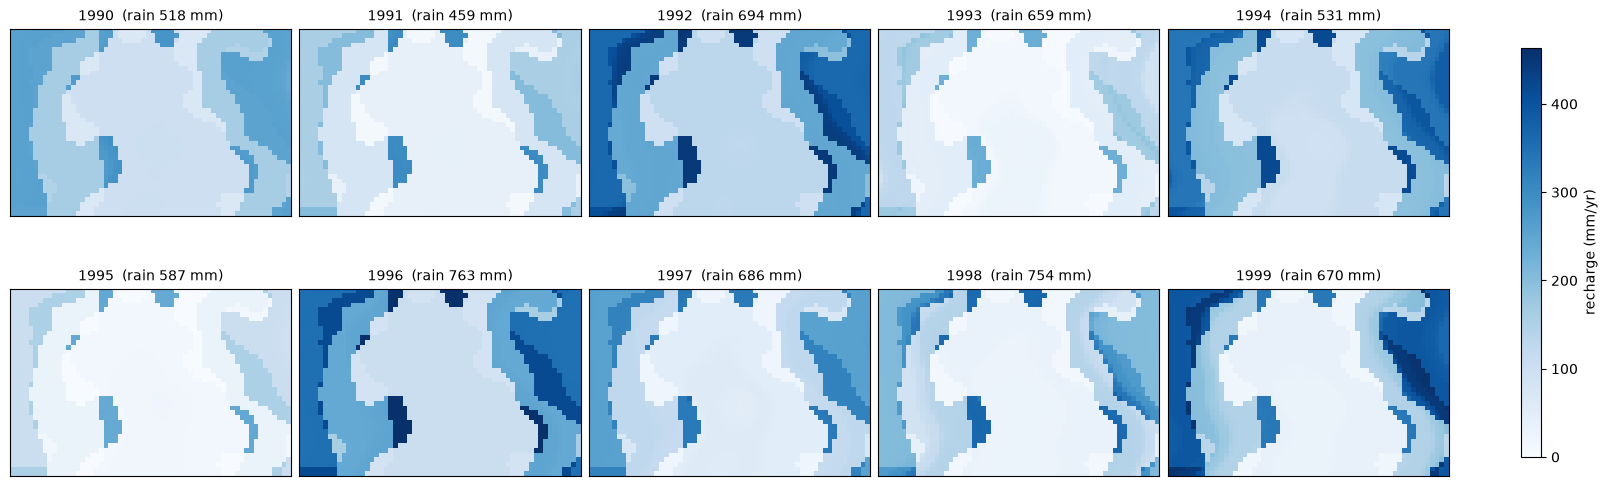

In [19]:
monthly = results["total_rech"].iloc[1:]
by_year = monthly.groupby((monthly.index - pd.Timedelta(days=1)).year).sum()

fig, axs = plt.subplots(2, 5, figsize=(16, 5.2), layout="constrained")
vmax = float(by_year.to_numpy().max() * 1000)
for ax, (year, row) in zip(axs.flat, by_year.iterrows(), strict=False):
    im = ax.imshow(hbd.to_map(row * 1000, land), origin="lower", cmap="Blues",
                   vmin=0, vmax=vmax)
    ax.set_title(f"{year}  (rain {clim.rainfall.loc[str(year)].sum() * 1000:.0f} mm)",
                 fontsize="medium")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axs, label="recharge (mm/yr)", shrink=0.8);

## 5. One- and two-store cells together

Cells need not share a structure. Over the palaeochannel the regolith is deep
enough to hold a second store below the root zone. `Model.with_` adds one to
those cells only, and the grid is rebuilt from the list of models.

Drainage from the root zone then passes through the lower store before
reaching the water table: it is delayed on its way *into* the lower store,
and released from it by the lower store's own drainage law. The lower store
has no potential evaporation here (`pot_evap_lower` defaults to zero).

In [20]:
lower = lr.LowerStore(maxvol=0.4, gamma=2.0, ks=0.02, m=0.5, l=0.5)
palaeo = land.deep_regolith.values.ravel()
mixed = lr.ModelGrid(
    cells=[cell.with_(lower=lower) if deep else cell
           for cell, deep in zip(grid.cells, palaeo, strict=True)],
    names=grid.names,
)
mixed

<ModelGrid: 2400 cells, 427 with a lower store>

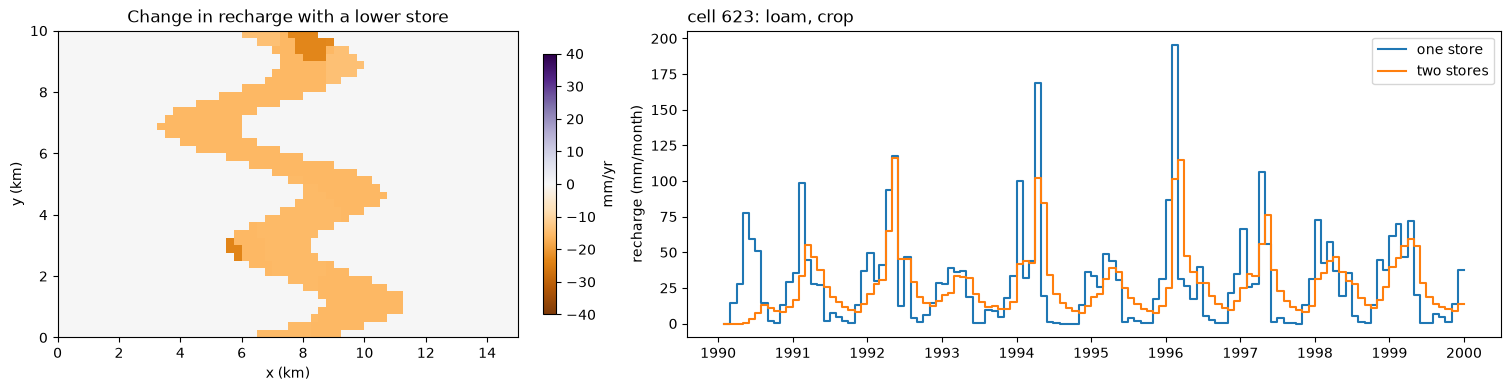

In [21]:
mixed_results = mixed.run(forcing, times="MS")
mixed_annual = mixed_results["total_rech"].sum() / nyears

k = int(np.flatnonzero(palaeo & (soil_code == 1))[0])
fig, axs = plt.subplots(1, 2, figsize=(15, 3.8), layout="constrained",
                        gridspec_kw=dict(width_ratios=[1, 1.6]))
hbd.plot_map(axs[0], (mixed_annual - annual["total_rech"]) * 1000, land,
             title="Change in recharge with a lower store", label="mm/yr", cmap="PuOr",
             vmin=-40, vmax=40)
axs[1].step(results.times, results["total_rech"][k] * 1000, label="one store")
axs[1].step(mixed_results.times, mixed_results["total_rech"][k] * 1000, label="two stores")
axs[1].set_ylabel("recharge (mm/month)")
axs[1].set_title(f"cell {k}: {cells.at[k, 'soil']}, {cells.at[k, 'landuse']}", loc="left")
axs[1].legend();

The lower store damps the recharge peaks and stretches them out, where the
drainage delay alone only shifts them. The ten-year total falls, by exactly
the water the lower store accumulates: it starts empty and ends the run
about 0.16 m full, and it loses nothing to evaporation here. A lower store
starting nearer its long-run volume, through `initial=InitialState(vol_lower=...)`,
or a spin-up period, removes that transient.

`from_arrays` builds a grid in which every cell has a lower store, with
`lower=dict(...)` taking arrays just as `upper` does. A mixed grid is built,
as here, from a list of models.

## 6. Speed

The compiled kernel steps cells in parallel on every core Numba may use (set
`NUMBA_NUM_THREADS` to limit it). The pure-Python kernel is the fallback when
Numba is not installed; it gives the same numbers, one cell at a time, and is
much slower. A 50-cell subset shows the difference.

In [22]:
subset = lr.ModelGrid(cells=grid.cells[:50], names=grid.names[:50])
runs, ms_per_cell = {}, {}
for engine in ("compiled", "python"):
    t0 = time.perf_counter()
    runs[engine] = subset.run(forcing, times="MS", engine=engine)
    ms_per_cell[engine] = (time.perf_counter() - t0) / subset.ncell * 1000
pd.Series(ms_per_cell, name="ms per cell, 10 years")

compiled     0.424661
python      22.769882
Name: ms per cell, 10 years, dtype: float64

In [23]:
np.array_equal(runs["compiled"].values, runs["python"].values, equal_nan=True)

True

**Next:** [03_spatial_forcing.ipynb](03_spatial_forcing.ipynb) gives each
cell its own forcing — a rainfall gradient, crop calendars and irrigation
districts — reads and writes it as netCDF, and returns results as gridded
xarray maps.